In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
folder = Path('./output/2025-12-01_12h07m50s_reconstr_grid_1')
dev = pd.read_csv(folder/'dev.csv')
test = pd.read_csv(folder/'test.csv')

In [14]:
# compiling dfs
folder = Path('./output/reconstr_grid1')
# dev = pd.read_csv(folder/'dev.csv')
# test = pd.read_csv(folder/'test.csv')

subfolders = ['t1', 't2', 't3', 't4', 't5']
dev = merge_devtest_csvs(folder, subfolders, 'dev.csv', save=True)
test = merge_devtest_csvs(folder, subfolders, 'test.csv', save=True)

# get confs, update
confs = ConfigLookup(
    keys=['embed_dim', 'hidden_dims', 'lr'],
    configs=dev['config'].unique().tolist(),
    path=folder,
    save=True,
).data

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')

# add log10lr
dev['log10lr'] = np.log10(dev['lr'])
test['log10lr'] = np.log10(test['lr'])

In [16]:
# filter outlier
test = test[(test['metric']=='mae') & (test['value'] < 1.0)]
test

,embed_dim,hidden_dims,lr,config,trial,metric,value,log10lr
3,16,0,0.10000,embeddim16_hiddendims0_lr0.1,0,mae,0.583203,-1.0
9,16,0,0.10000,embeddim16_hiddendims0_lr0.1,1,mae,0.575545,-1.0
15,16,0,0.10000,embeddim16_hiddendims0_lr0.1,2,mae,0.580935,-1.0
21,16,0,0.10000,embeddim16_hiddendims0_lr0.1,3,mae,0.571093,-1.0
27,16,0,0.10000,embeddim16_hiddendims0_lr0.1,4,mae,0.575950,-1.0
...,...,...,...,...,...,...,...,...
11523,256,6,0.00001,embeddim256_hiddendims6_lr1e-5,6,mae,0.606945,-5.0
11529,256,6,0.00001,embeddim256_hiddendims6_lr1e-5,7,mae,0.599812,-5.0
11535,256,6,0.00001,embeddim256_hiddendims6_lr1e-5,8,mae,0.603657,-5.0
11541,256,6,0.00001,embeddim256_hiddendims6_lr1e-5,9,mae,0.630670,-5.0


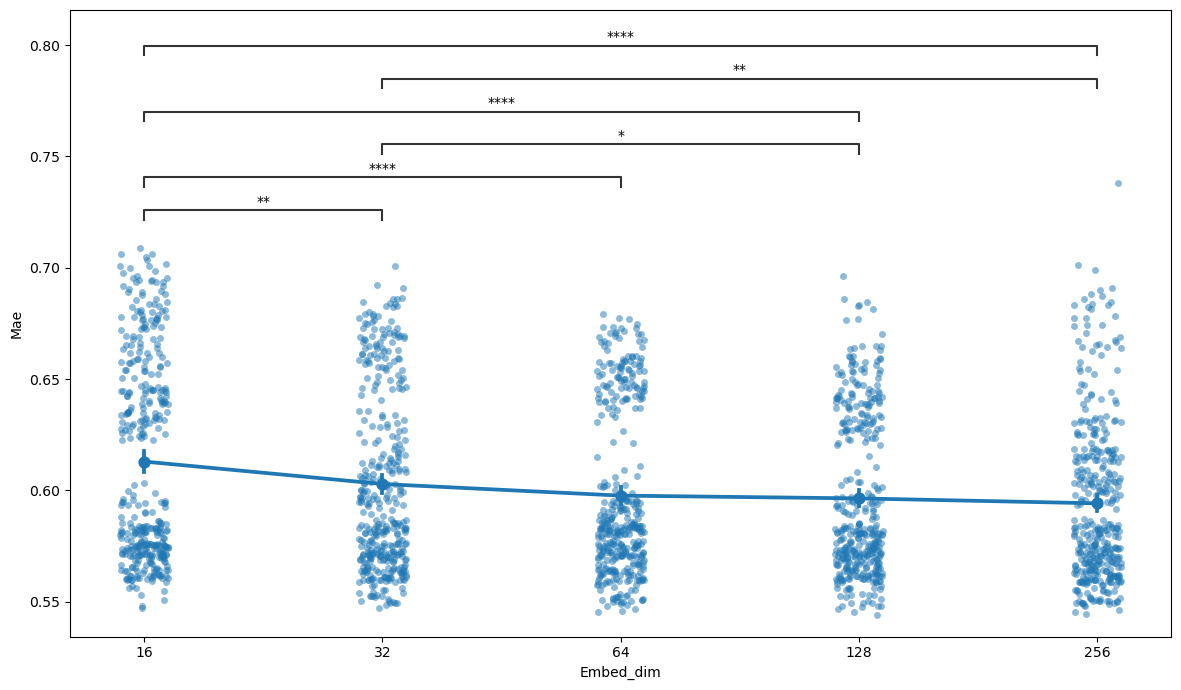

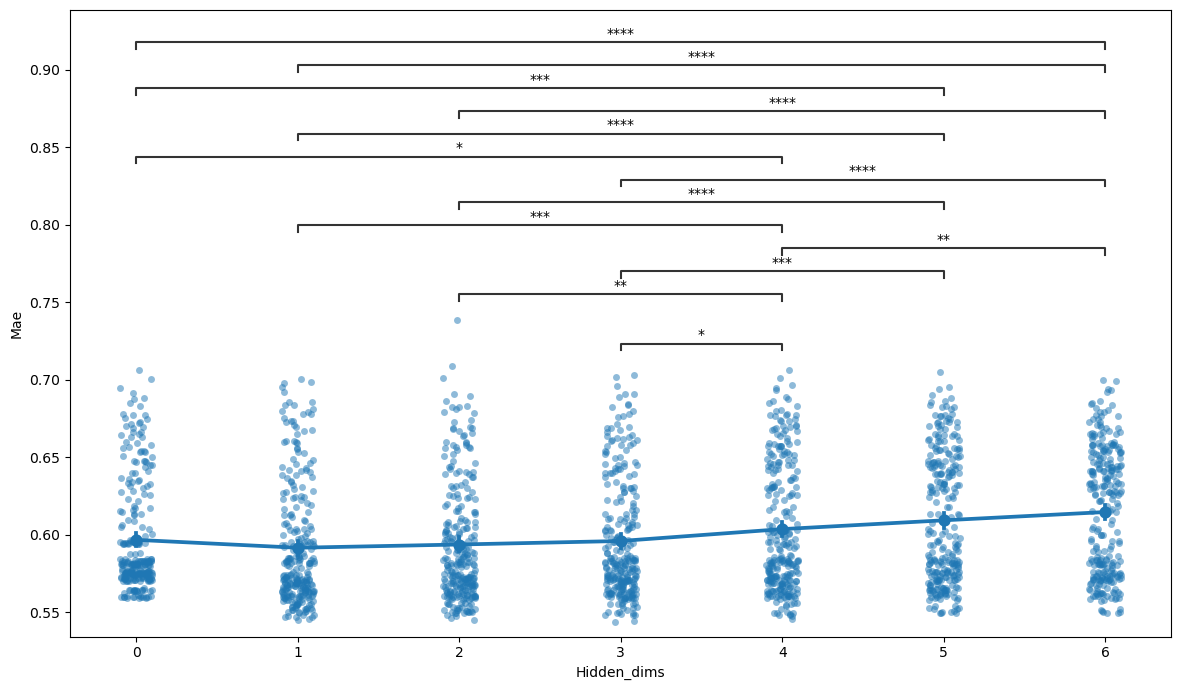

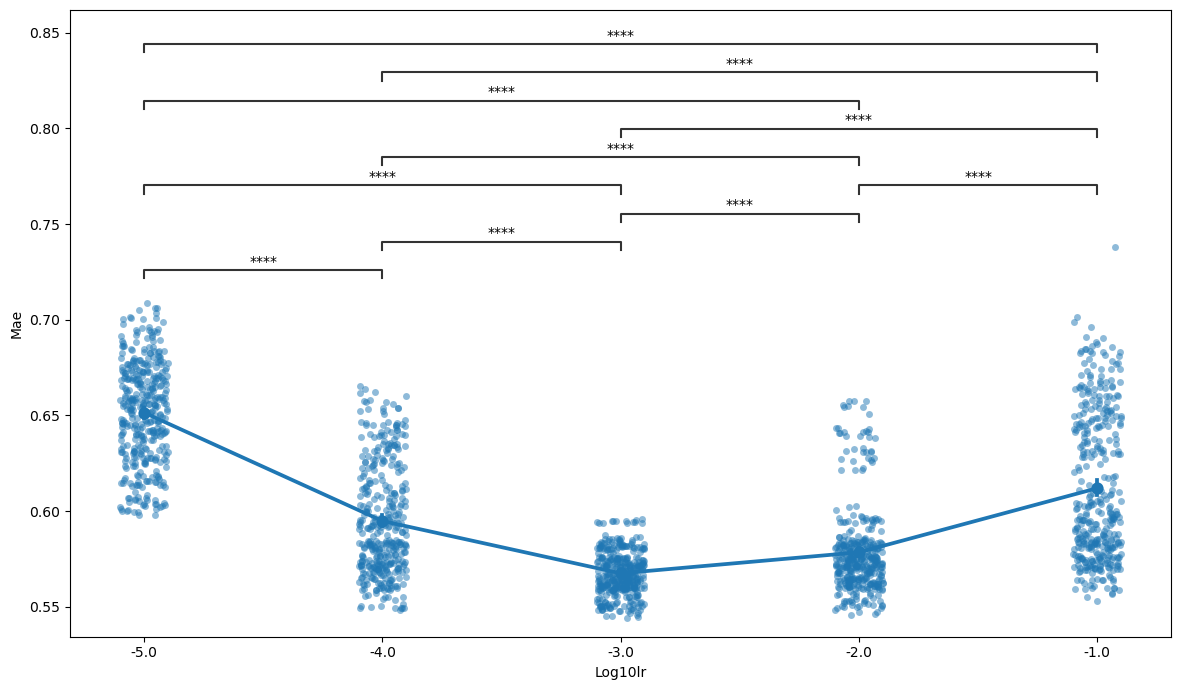

In [17]:
metric_x_point(
    df=test, 
    cols=['embed_dim', 'hidden_dims', 'log10lr'],
    metrics=['mae'],
    figsize=(12,7),
    strip=True,
    sig=True
)

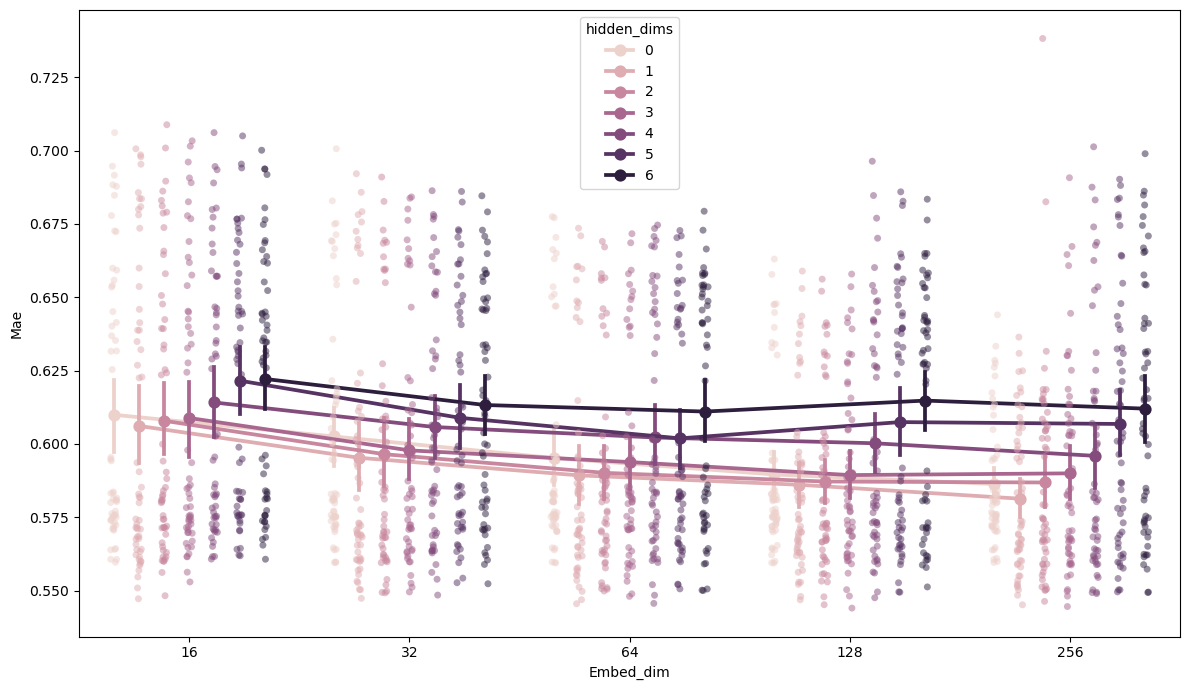

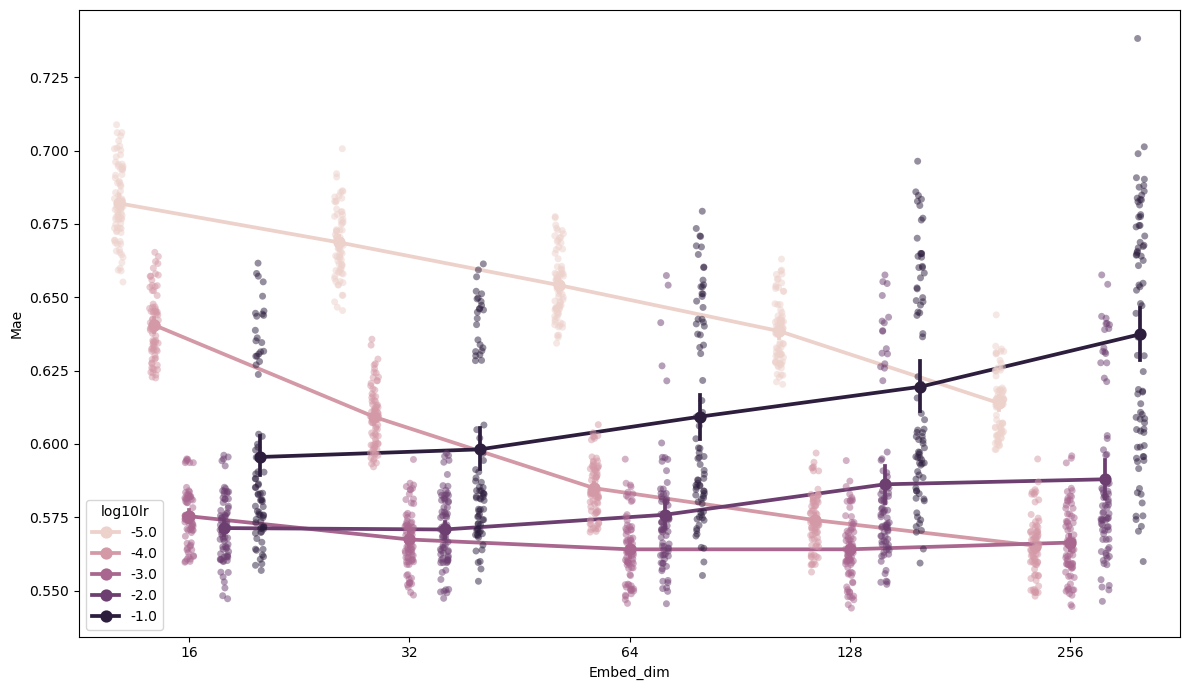

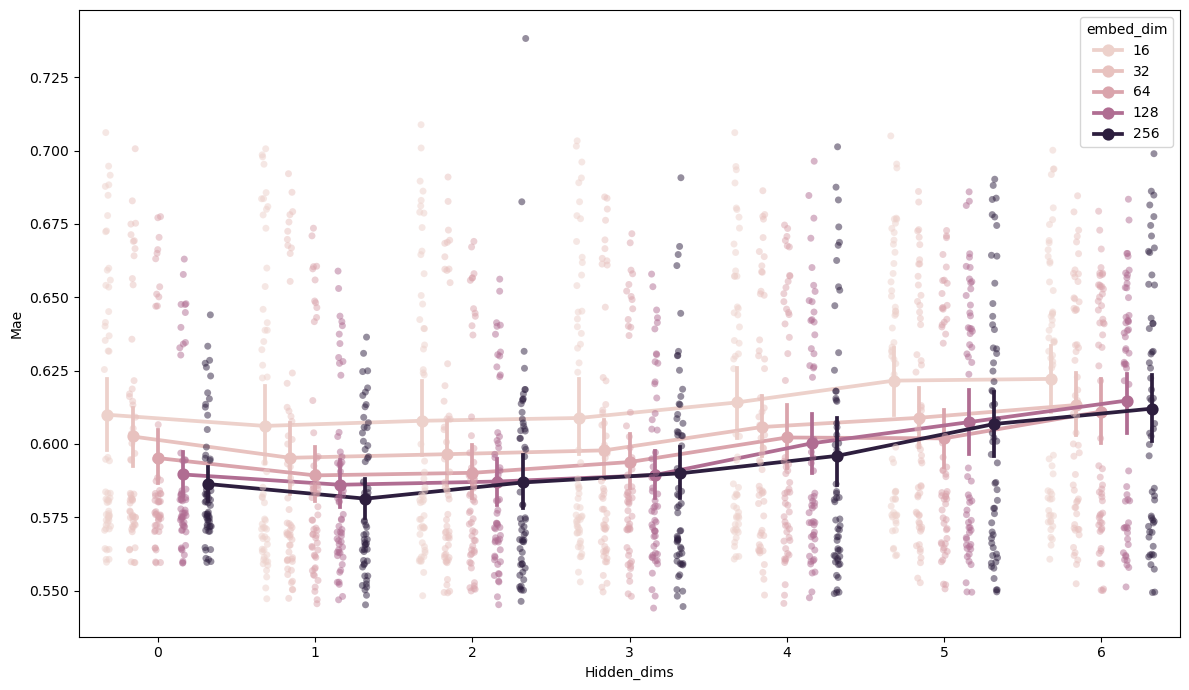

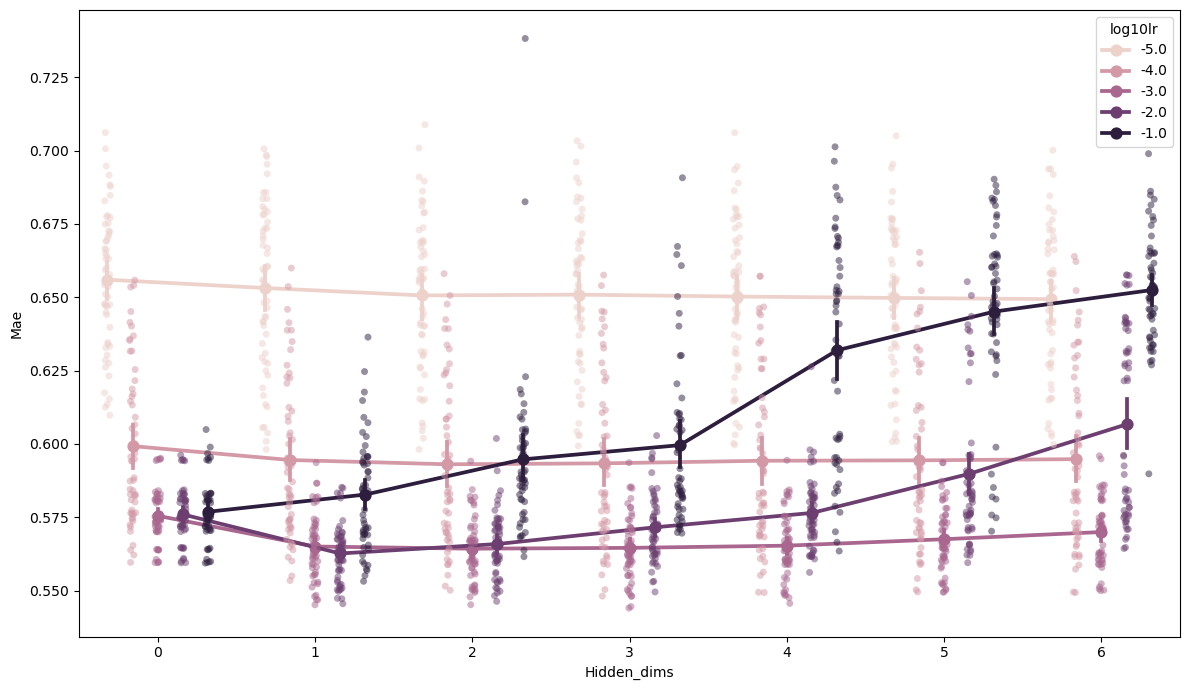

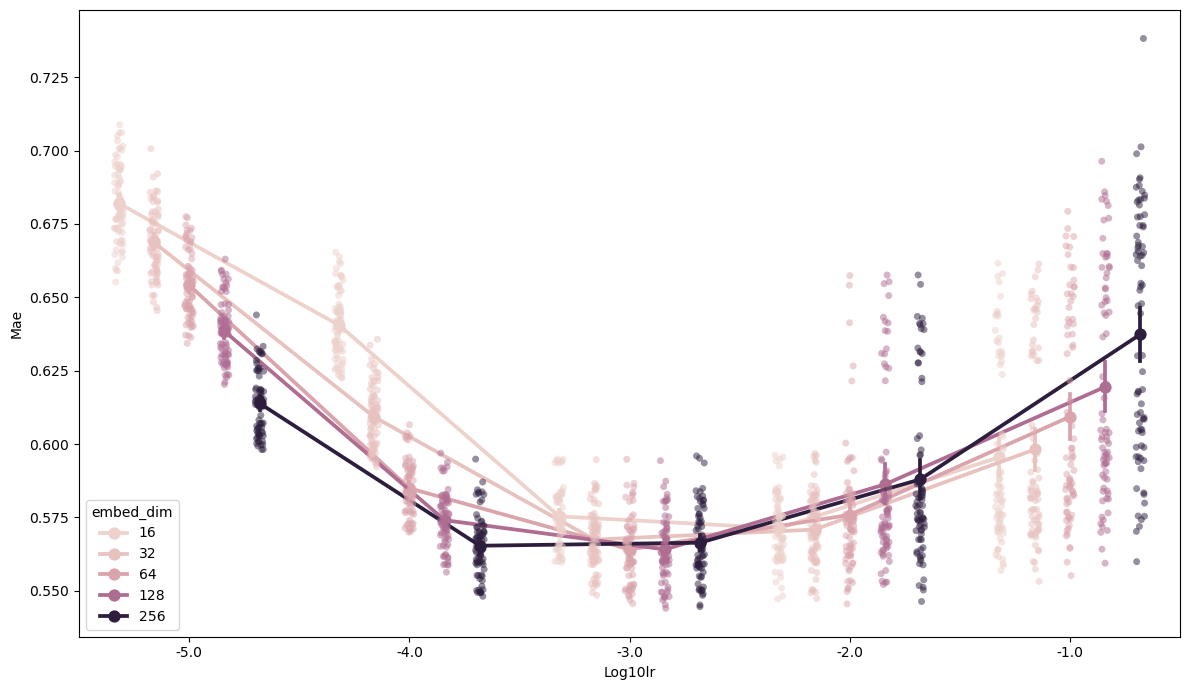

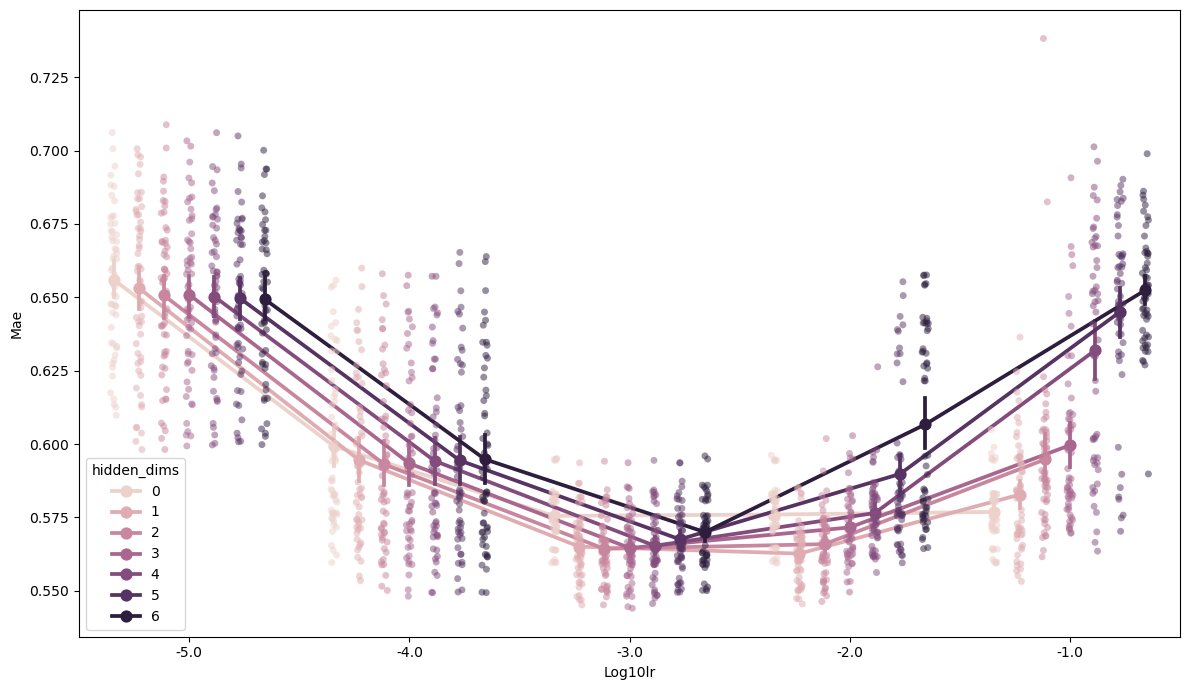

In [18]:
metric_x_point(
    df=test, 
    cols=['embed_dim', 'hidden_dims', 'log10lr'],
    metrics=['mae'],
    figsize=(12,7),
    hue=True,
    strip=True,
    dodge=True,
    sig=False
)